# **Librerías**

In [1]:
# @title
import math
import os
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

# **Funciones para BackPropagation**

In [2]:
# @title
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other
  def sigmoid(self):
    import math
    x = self.data
    s = 1 / (1 + math.exp(-x))
    out = Value(s, (self,), 'sigmoid')

    def _backward():
        # σ'(x) = σ(x) * (1 - σ(x))
        self.grad += (s * (1 - s)) * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out
  def log(self):
      assert self.data > 0, "log requiere argumento > 0"
      out = Value(math.log(self.data), (self,), 'log')
      def _backward():
        self.grad += (1.0 / self.data) * out.grad
      out._backward = _backward
      return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

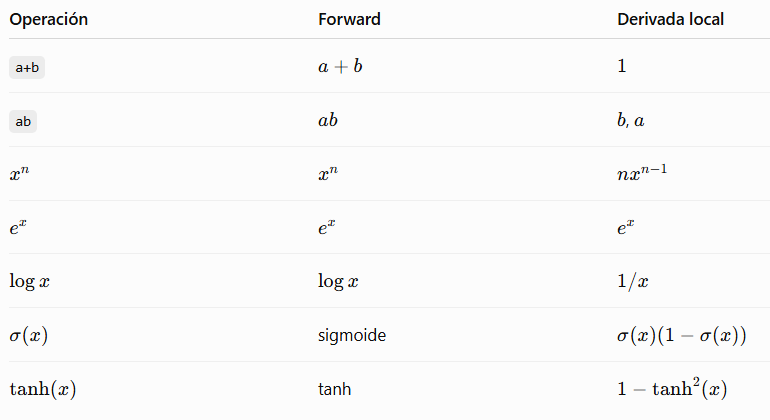

# **Funciones para el Grafo Computacional (recorrer el grafo computacional que Micrograd construyó y dibujarlo con Graphvi)**

In [3]:
# @title
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):          #función que mira el recorrido del grafo
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):    #funcion que dibuja
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


**Armando un Grafo Cualquiera**

In [4]:
a = Value(2.0, label='a')
print(a)
b = Value(-3.0, label='b')
print(b)
c = Value(10.0, label='c')
print(c)
e = a*b; e.label = 'e'
print(e)
d = e + c; d.label = 'd'
print(d)
f = Value(-2.0, label='f')
print(f)
L = d * f; L.label = 'L'
print(L)

Value(data=2.0)
Value(data=-3.0)
Value(data=10.0)
Value(data=-6.0)
Value(data=4.0)
Value(data=-2.0)
Value(data=-8.0)


**Graficando el Grafo**

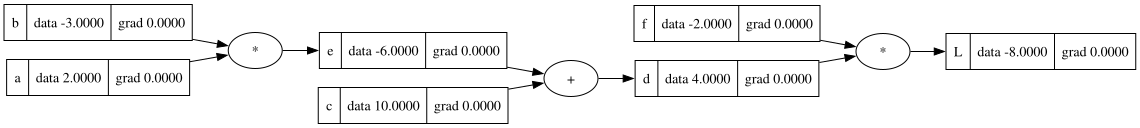

In [5]:
draw_dot(L)

**Comando para colcoar el Grad en el punto del Grafo**

In [6]:
f.grad=4.0

**Comando para Generación de Backpropagation en todos los nodos**

In [7]:
L.backward()

# **Perceptron neuron**

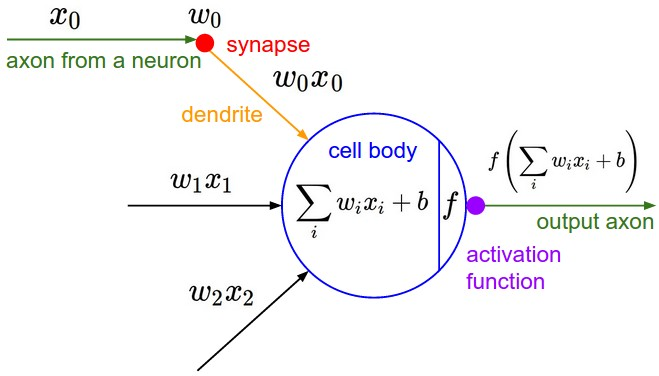

In [8]:
import math

def cross_entropy_compact(o, y):
    # y techito (o): valor predecido; y: valor real
    yv = y if isinstance(y, Value) else Value(float(y), label='y')

    # forward numérico
    L = - (yv.data * math.log(o.data) + (1 - yv.data) * math.log(1 - o.data))

    out = Value(L, (o,), 'cross_entropy')   # solo depende de 'o', o = salida del modelo (probabilidad, y_pred)
    out.label = 'cross_entropy'

    # dL/do = (o - y) / (o * (1 - o))
    def _backward():
        o.grad += ((o.data - yv.data) / (o.data * (1 - o.data))) * out.grad
    out._backward = _backward
    return out


**Realizamos el Fordward (Epoch=0)**

In [9]:
# inputs x1,x2
x1 = Value(1.0, label='x1')
x2 = Value(1.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(2.0, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
y_pred = n.sigmoid(); y_pred.label = 'y_pred'
# pérdida
y_true = Value(1.0, label='y')   # etiqueta como Value
L = cross_entropy_compact(y_pred, y_true); L.label = 'L'

**Graficamos el Grafo de Perceptron (Epoch=0)**

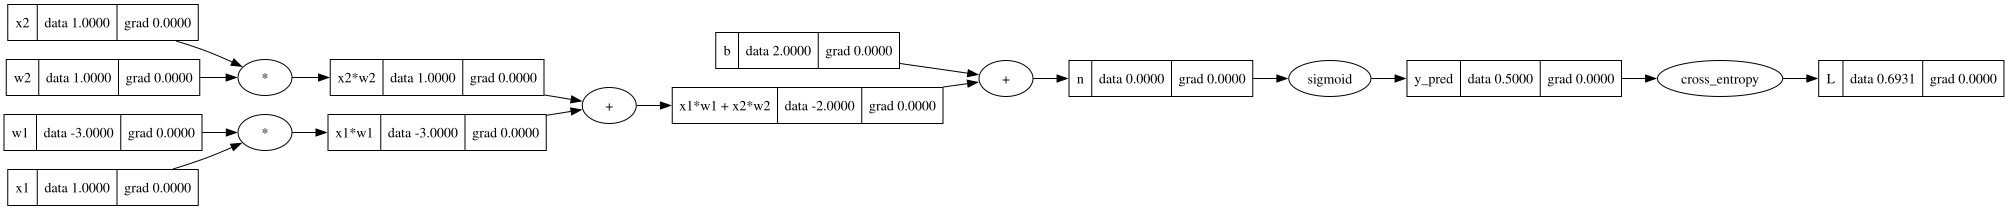

In [10]:
draw_dot(L)

**Backpropagation de Perceptron (Epoch=0)**

In [11]:
L.backward()

**Actualización de los Pesos y bieas**

In [12]:
lr=0.01
# Update de parámetros (descenso por gradiente)
w1.data = w1.data - lr * w1.grad   # w1^(1) = w1^(0) - lr * dL/dw1
w2.data = w2.data - lr * w2.grad   # w2^(1) = w2^(0) - lr * dL/dw2
b.data  = b.data  - lr * b.grad    # b^(1)  = b^(0) - lr * dL/db

print(f"w1 = {w1.data:.6f}, w2 = {w2.data:.6f}, b = {b.data:.6f}")

w1 = -2.995000, w2 = 1.005000, b = 2.005000


**Realizamos el Fordward (Epoch=1)**

In [13]:
# inputs x1,x2
x1 = Value(1.0, label='x1')
x2 = Value(1.0, label='x2')
# weights w1,w2
w1 = Value(-2.995, label='w1')
w2 = Value(1.005, label='w2')
# bias of the neuron
b = Value(2.005, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
y_pred = n.sigmoid(); y_pred.label = 'y_pred'
# pérdida
y_true = Value(1.0, label='y')   # etiqueta como Value
L = cross_entropy_compact(y_pred, y_true); L.label = 'L'

**Graficamos el Grafo de Perceptron (Epoch=2)**

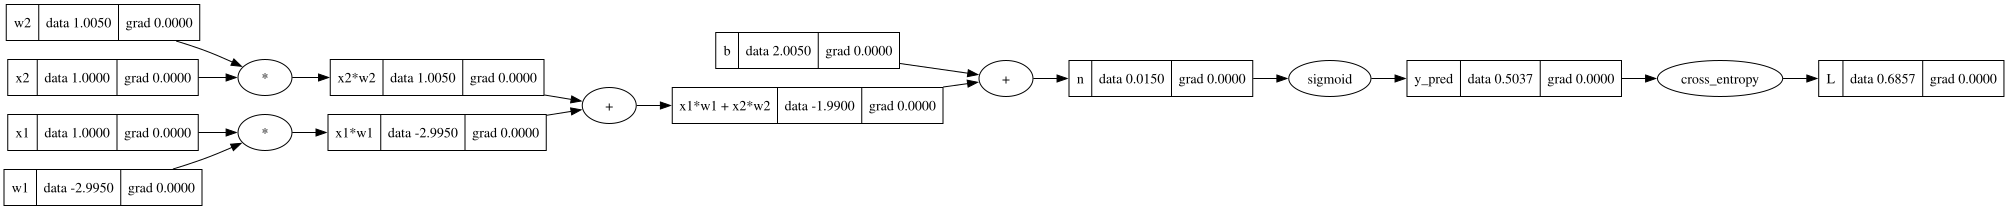

In [14]:
draw_dot(L)

**Backpropagation de Perceptron (Epoch=2)**

In [15]:
L.backward()



# **Realizamos el entrenamiento con Epoch=200 de manera automática para la compuerta AND**

epoch 000 | loss = 0.916696
epoch 001 | loss = 0.887037
epoch 020 | loss = 0.518815
epoch 040 | loss = 0.385709
epoch 060 | loss = 0.342443
epoch 080 | loss = 0.323006
epoch 100 | loss = 0.310050
epoch 120 | loss = 0.299293
epoch 140 | loss = 0.289619
epoch 160 | loss = 0.280690
epoch 180 | loss = 0.272372
epoch 199 | loss = 0.264964

Predicciones finales (sigmoid) y CE por muestra:
(0, 0) -> out≈0.0541  y_pred=0  y_true=0  CE≈0.0556
(0, 1) -> out≈0.2243  y_pred=0  y_true=0  CE≈0.2540
(1, 0) -> out≈0.2580  y_pred=0  y_true=0  CE≈0.2984
(1, 1) -> out≈0.6375  y_pred=1  y_true=1  CE≈0.4503

Parámetros aprendidos:
w1 = 1.8049217775970716
w2 = 1.6206832296208513
b = -2.861249135946085


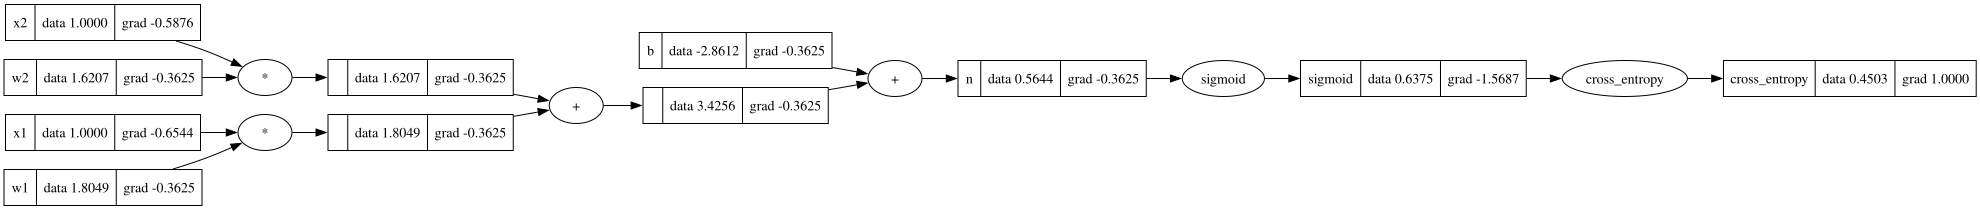

In [16]:
import math, random
# DATASET AND
xs = [(0.0, 0.0),
      (0.0, 1.0),
      (1.0, 0.0),
      (1.0,1.0)]
ys = [0.0, 0.0, 0.0,1.0]  # y_true

# PARÁMETROS (inicialización)
random.seed(0)
w1 = Value(random.uniform(-3, 3), label='w1')
w2 = Value(random.uniform(-3, 3), label='w2')
b  = Value(random.uniform(-3, 3), label='b')
#w1 = Value(-7.0, label='w1')
#w2 = Value(5.2, label='w2')
#b  = Value(7.0, label='b')
params = [w1, w2, b]

#  FORWARD  (arquitectura de la neurona)
def forward_neuron(x1_float, x2_float):
    x1 = Value(x1_float, label='x1')
    x2 = Value(x2_float, label='x2')
    n  = x1*w1 + x2*w2 + b; n.label = 'n'
    o  = n.sigmoid();      o.label = 'sigmoid'
    return o

# ENTRENAMIENTO
# Configurar los hyperparámetros
lr = 0.1
epochs = 200

for k in range(epochs):
    # 1) forward + loss
    sample_losses = [cross_entropy_compact(forward_neuron(x1, x2), y_true)   # forward_neuron(x1, x2) denota el y_predecido
                     for (x1, x2), y_true in zip(xs, ys)]
    loss = sum(sample_losses) * (1.0/len(xs))    #promedio de la pérdida (loss) sobre todas las muestras del datas
    loss.label = 'loss'

    # 2) backward (Backpropagation en los pesos y bias)
    for p in params:
        p.grad = 0.0
    loss.backward()

    # 3) update (Uso de Gradiente Descendiente)
    for p in params:
        p.data += -lr * p.grad

    if k % 20 == 0 or k == epochs - 1 or k==1:
        print(f"epoch {k:03d} | loss = {loss.data:.6f}")




# EVALUACIÓN (forward + CE en una sola llamada)
print("\nPredicciones finales (sigmoid) y CE por muestra:")
for (x1f, x2f), y_true in zip(xs, ys):
    # forward + CE de una sola vez
    L_sample = cross_entropy_compact(forward_neuron(x1f, x2f), y_true)
    yout = L_sample._prev.pop()

    pred = 1 if yout.data >= 0.5 else 0
    print(f"({int(x1f)}, {int(x2f)}) -> out≈{yout.data:.4f}  y_pred={pred}  y_true={int(y_true)}  CE≈{L_sample.data:.4f}")

print("\nParámetros aprendidos:")
for p in params:
    print(p.label, "=", p.data)

# ====== Grafo: ahora DESPUÉS de la cross-entropy  ======
for p in params:
    p.grad = 0.0

# ejemplo (1,1)
L_vis = cross_entropy_compact(forward_neuron(1.0, 1.0), 1.0)  # forward + CE en una
L_vis.backward()  # para ver gradientes
draw_dot(L_vis)   # dibuja desde la loss hacia atrás


# **DEBER 2: BACKPROPAGATION**

**Realizar el Forward, Backpropagation, Gradiente Descendiern de la siguiente arquitectura de red para el modelo aprenda una compuerta XOR**

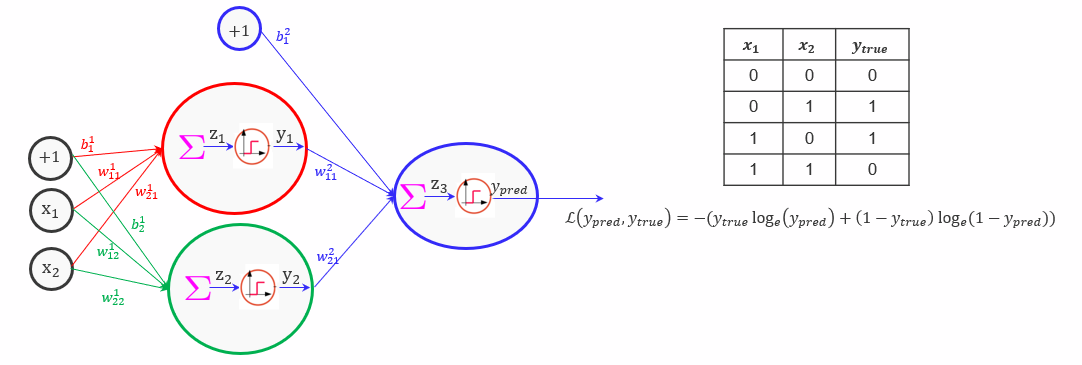

epoch 0000 | loss = 0.695087
epoch 0300 | loss = 0.524904
epoch 0600 | loss = 0.054711
epoch 0900 | loss = 0.021259
epoch 1200 | loss = 0.012943
epoch 1500 | loss = 0.009251
epoch 1800 | loss = 0.007180
epoch 2100 | loss = 0.005859
epoch 2400 | loss = 0.004944
epoch 2700 | loss = 0.004274
epoch 2999 | loss = 0.003764

Predicciones finales (sigmoid) para la compuerta XOR:
(0, 0) -> y_pred≈0.0047  clase=0  y_true=0
(0, 1) -> y_pred≈0.9966  clase=1  y_true=1
(1, 0) -> y_pred≈0.9966  clase=1  y_true=1
(1, 1) -> y_pred≈0.0035  clase=0  y_true=0

Parámetros aprendidos (recorriendo la red capa por capa, neurona por neurona):
Capa 0:
  Neurona 0: w0=7.3082, w1=7.3128, b=-3.3352
  Neurona 1: w0=5.4840, w1=5.4848, b=-8.3905
Capa 1:
  Neurona 0: w0=12.3704, w1=-13.1649, b=-5.7744


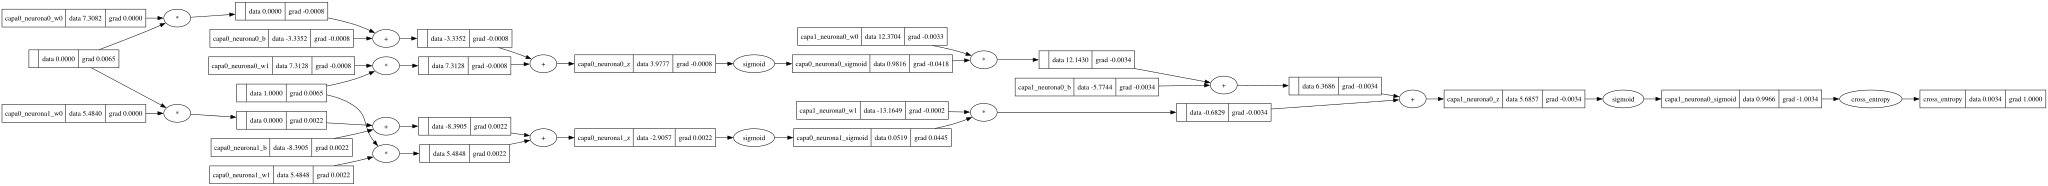

In [17]:
#Inserte su codigo

# ============================================================
#  RED NEURONAL GENÉRICA PARA LA COMPUERTA XOR (arquitectura 2-2-1)
# ------------------------------------------------------------
#  En vez de "quemar" una variable por cada peso/bias (w1_11, w1_21,
#  b1_1, w1_12, w1_22, b1_2, w2_11, w2_21, b2_1, como se haría a
#  mano), se define una pequeña jerarquía de clases reutilizables
#  -siguiendo el principio DRY (Don't Repeat Yourself)- que arma la
#  red de forma programática a partir de una lista de tamaños:
#
#     NeuronaSigmoide -> combina sus entradas (w·x + b) y aplica
#                         sigmoide. Es la única pieza que sabe
#                         "hacer una neurona"; todo lo demás la
#                         reutiliza en vez de repetir su código.
#     CapaDensa       -> varias NeuronaSigmoide en paralelo que
#                         reciben la MISMA entrada x (una capa).
#     RedNeuronal     -> conecta las capas en serie: la salida de
#                         la capa i (una lista de Value) pasa a ser
#                         la entrada de la capa i+1, sin que el
#                         usuario tenga que nombrar y1, y2, ... a mano.
#
#  Con esto, la arquitectura del diagrama (2 entradas -> 2 neuronas
#  ocultas -> 1 salida, todas con sigmoide) se arma con una sola
#  línea: RedNeuronal(n_entradas=2, arquitectura=[2, 1]). Cambiar el
#  número de neuronas o agregar una capa es solo cambiar esa lista,
#  no escribir más código.
#
#  En este notebook conviven dos conjuntos de clases de forma
#  intencional:
#
#     NeuronaSigmoide, CapaDensa, RedNeuronal y entrenar
#     forman la implementación genérica introducida en esta sección
#     para la red XOR. Permiten construir arquitecturas y reutilizar
#     el mismo bucle de entrenamiento.
#
#     Neuron, Layer y MLP pertenecen a la implementación original de
#     la sección posterior, que se conserva para comparar otra API y
#     otra arquitectura de red.
#
#  Las dos implementaciones se mantienen separadas a propósito para
#  evitar cambios en cascada (ripple changes): la nueva abstracción
#  puede evolucionar sin modificar ni romper el código educativo
#  original de Neuron, Layer y MLP.
# ============================================================

import math, random

class NeuronaSigmoide:
    """Una neurona: z = w·x + b, seguido de sigmoide(z)."""

    def __init__(self, n_entradas, etiqueta="neurona"):
        # Validación y etiquetas: cada neurona identifica sus parámetros
        # y nodos para evitar entradas incompatibles y mejorar Graphviz.
        self.etiqueta = etiqueta
        self.w = [Value(random.uniform(-1, 1), label=f"{etiqueta}_w{i}") for i in range(n_entradas)]
        self.b = Value(random.uniform(-1, 1), label=f"{etiqueta}_b")

    def __call__(self, x):
        # Validación explícita: zip() podría ocultar entradas faltantes o sobrantes.
        if len(x) != len(self.w):
            raise ValueError(
                f"{self.etiqueta} esperaba {len(self.w)} entradas y recibió {len(x)}"
            )
        x = [xi if isinstance(xi, Value) else Value(xi, label=f"{self.etiqueta}_x{i}")
             for i, xi in enumerate(x)]
        z = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)  # w·x + b
        z.label = f"{self.etiqueta}_z"
        out = z.sigmoid()
        out.label = f"{self.etiqueta}_sigmoid"
        return out

    def parameters(self):
        return self.w + [self.b]


class CapaDensa:
    """Una capa = varias NeuronaSigmoide en paralelo, todas recibiendo la misma x."""

    def __init__(self, n_entradas, n_neuronas, indice_capa=0):
        self.neuronas = [
            NeuronaSigmoide(n_entradas, etiqueta=f"capa{indice_capa}_neurona{j}")
            for j in range(n_neuronas)
        ]

    def __call__(self, x):
        # cada neurona de la capa procesa la misma entrada x de forma independiente
        return [neurona(x) for neurona in self.neuronas]

    def parameters(self):
        return [p for neurona in self.neuronas for p in neurona.parameters()]


class RedNeuronal:
    """
    Red = lista de capas conectadas en serie: la salida de la capa i
    alimenta a la capa i+1. 'arquitectura' es el número de neuronas
    por cada capa oculta/salida (el tamaño de entrada se da aparte),
    ej. arquitectura=[2, 1] -> 2 neuronas ocultas + 1 de salida.
    """

    def __init__(self, n_entradas, arquitectura):
        tamanos = [n_entradas] + arquitectura
        self.capas = [
            CapaDensa(tamanos[i], tamanos[i + 1], indice_capa=i)
            for i in range(len(arquitectura))
        ]

    def __call__(self, x):
        x = [xi if isinstance(xi, Value) else Value(xi) for xi in x]
        for capa in self.capas:
            x = capa(x)  # la salida de esta capa es la entrada de la siguiente
        return x[0] if len(x) == 1 else x  # si la última capa tiene 1 neurona, regresa el Value directo

    def parameters(self):
        return [p for capa in self.capas for p in capa.parameters()]


def entrenar(red, xs, ys, loss_fn, lr, epochs, print_every=None):
    """Bucle de entrenamiento genérico: Forward + Backpropagation + Gradiente Descendiente."""
    historial = []
    # Caché de parámetros: la estructura de la red no cambia durante el entrenamiento.
    parametros = red.parameters()
    for k in range(epochs):
        # 1) forward + loss promedio sobre todo el dataset
        perdidas = [loss_fn(red(list(x)), y) for x, y in zip(xs, ys)]
        loss = sum(perdidas) * (1.0 / len(xs))

        # 2) backward (se resetean los gradientes antes de propagar)
        for p in parametros:
            p.grad = 0.0
        loss.backward()

        # 3) update (descenso de gradiente)
        for p in parametros:
            p.data += -lr * p.grad

        historial.append(loss.data)
        if print_every and (k % print_every == 0 or k == epochs - 1):
            print(f"epoch {k:04d} | loss = {loss.data:.6f}")
    return historial


# ---- DATASET XOR (igual a la tabla de verdad del diagrama) ----
xs = [(0.0, 0.0),
      (0.0, 1.0),
      (1.0, 0.0),
      (1.0, 1.0)]
ys = [0.0, 1.0, 1.0, 0.0]  # y_true: XOR(x1, x2)

# ---- CONSTRUCCIÓN DE LA RED (2 entradas -> 2 ocultas -> 1 salida) ----
# Toda la arquitectura del diagrama queda definida en esta sola línea:
random.seed(0)
xor_net = RedNeuronal(n_entradas=2, arquitectura=[2, 1])

# ---- ENTRENAMIENTO ----
# XOR no es separable linealmente, así que hacen falta más épocas y un
# learning rate mayor que en la compuerta AND (que sí es lineal) para que
# la red atraviese la meseta inicial y converja.
historial = entrenar(xor_net, xs, ys, loss_fn=cross_entropy_compact,
                      lr=1.0, epochs=3000, print_every=300)

# ---- EVALUACIÓN ----
print("\nPredicciones finales (sigmoid) para la compuerta XOR:")
for (x1f, x2f), y_true in zip(xs, ys):
    y_pred = xor_net([x1f, x2f])
    pred = 1 if y_pred.data >= 0.5 else 0
    print(f"({int(x1f)}, {int(x2f)}) -> y_pred≈{y_pred.data:.4f}  clase={pred}  y_true={int(y_true)}")

print("\nParámetros aprendidos (recorriendo la red capa por capa, neurona por neurona):")
for i, capa in enumerate(xor_net.capas):
    print(f"Capa {i}:")
    for j, neurona in enumerate(capa.neuronas):
        pesos = ", ".join(f"w{k}={w.data:.4f}" for k, w in enumerate(neurona.w))
        print(f"  Neurona {j}: {pesos}, b={neurona.b.data:.4f}")

# ---- GRAFO: visualizamos el grafo computacional para un caso, ej. (0,1) ----
for p in xor_net.parameters():
    p.grad = 0.0
L_vis = cross_entropy_compact(xor_net([0.0, 1.0]), 1.0)
L_vis.backward()
draw_dot(L_vis)


## **Pytorch**

https://pytorch.org/

In [18]:
import math

def cross_entropy_compact(o, y):
    # y techito (o): valor predicho; y: valor real
    yv = y if isinstance(y, Value) else Value(float(y), label='y')

    # Estabilidad numérica: evitamos log(0) y log(1 - 1),
    # que producirían errores de dominio o gradientes infinitos.
    epsilon = 1e-7
    o_data = min(max(o.data, epsilon), 1.0 - epsilon)

    # La pérdida usa la probabilidad recortada para mantenerse finita
    # incluso cuando la sigmoide se aproxima demasiado a 0 o a 1.
    L = -(yv.data * math.log(o_data) + (1 - yv.data) * math.log(1 - o_data))

    out = Value(L, (o,), 'cross_entropy')
    out.label = 'cross_entropy'

    # El gradiente usa el mismo valor recortado para evitar divisiones
    # por cero y conservar la estabilidad durante backpropagation.
    def _backward():
        o.grad += ((o_data - yv.data) / (o_data * (1 - o_data))) * out.grad
    out._backward = _backward
    return out


In [19]:
import torch
import torch.nn as nn

# Variables y parámetros
x1 = torch.Tensor([1.0,1.0,0.0,0.0]).double(); x1.requires_grad = False
x2 = torch.Tensor([1.0,0.0,1.0,0.0]).double(); x2.requires_grad = False
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([2.0]).double(); b.requires_grad = True

# Forward: neurona + sigmoide
n = x1*w1 + x2*w2 + b   # Operación elemento a elemento
o = torch.sigmoid(n)    # Salida sigmoide para cada entrada

# Mostrar las salidas (4 elementos)
print("Salidas sigmoide:", o.detach().numpy())

# Etiqueta (target)
y = torch.tensor([1.0,0.0,0.0,0.0], dtype=torch.double)

# Definir pérdida BCE
criterion = nn.BCELoss()
loss = criterion(o, y)

print("Cross-Entropy Loss:", loss.item())

# Backward
loss.backward()

print('--- Gradientes ---')
print('w1:', w1.grad.item())
print('w2:', w2.grad.item())
print('b :', b.grad.item())


Salidas sigmoide: [0.5        0.26894142 0.95257413 0.88079708]
Cross-Entropy Loss: 1.545481057673721
--- Gradientes ---
w1: -0.057764644657501224
w2: 0.11314353170560834
b : 0.40057815654257767


**Redes Neuronales**

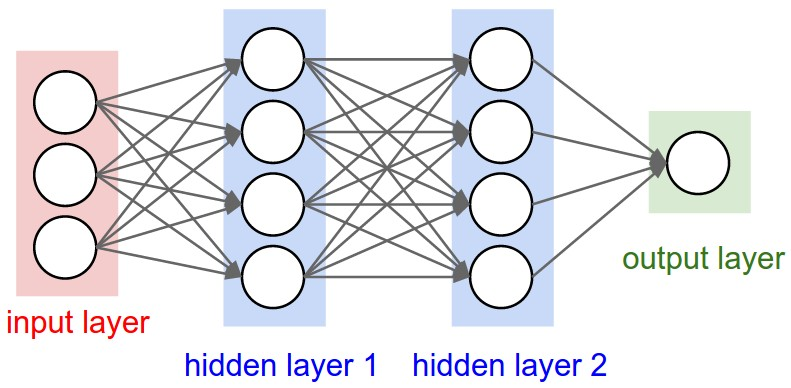

# **Definimos las Clase y funciones para MPL**

In [20]:
# @title

class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:  # Multilayer Perceptron

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

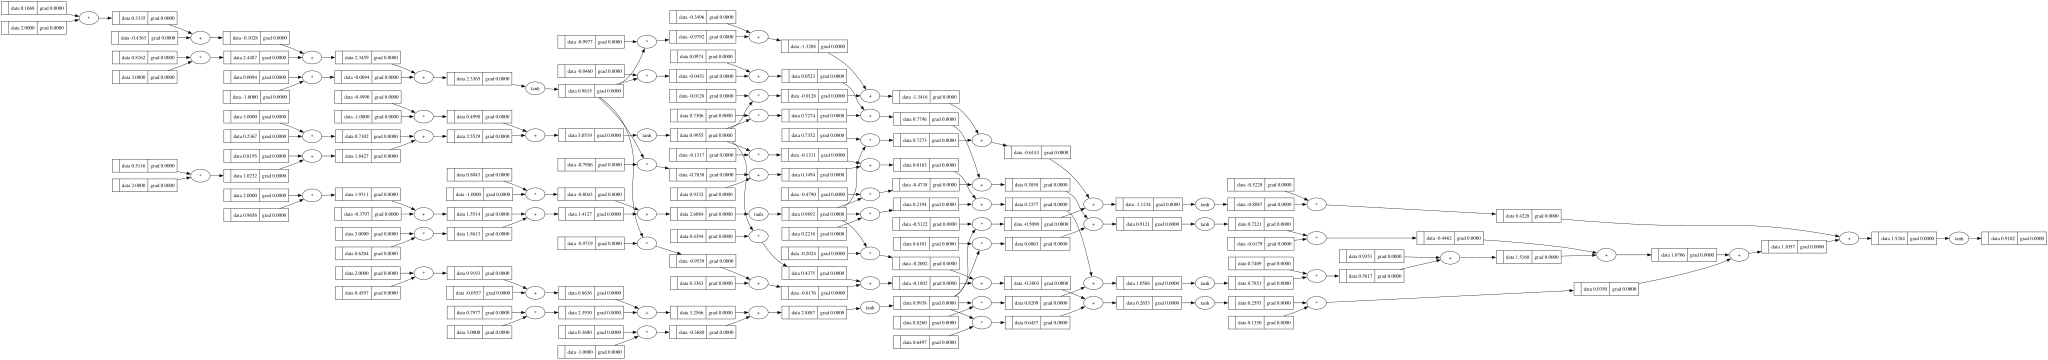

In [21]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
draw_dot(n(x))

**Entrenar la red a partir de los datos y backpropagation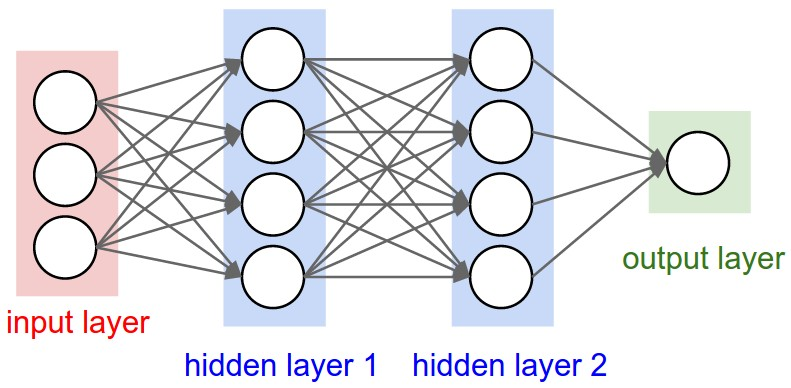**

In [22]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

**A continuación no predice bien porque se comenzó con valores aleatorios y no esta entrenada la red con backpropagation**

In [23]:
ypred = [n(x) for x in xs]
print(ypred)

[Value(data=0.9101569149050596), Value(data=0.7942483463711185), Value(data=0.9181457360655514), Value(data=0.905161074559645)]


**1. Defininos la Función objetivo (Loss) que sera la Mean Square Error (igual que en la LR)**

In [24]:
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=0.008071779939376708),
 Value(data=3.219327128455493),
 Value(data=3.679283064786456),
 Value(data=0.008994421778681214)]

In [25]:
loss=sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)])
print(loss)

Value(data=6.915676394960007)


**2. Minimizamos la función los encontrando los pesos de la red**

In [26]:
for k in range(20):

  # loss function
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

# Se recalculan las predicciones después de la última actualización de pesos.
# Así, la salida mostrada corresponde al estado final entrenado del MLP.
ypred = [n(x) for x in xs]


0 6.915676394960007
1 4.695362269747642
2 3.191825287150228
3 4.6811533811364106
4 0.6480903137520828
5 0.2887337588888189
6 0.16363261144830715
7 0.1221597512672779
8 0.0982580460932042
9 0.08198075602630278
10 0.07018499792795607
11 0.061252008124071014
12 0.05425964376386189
13 0.048643144603198143
14 0.04403706544064284
15 0.04019444504018677
16 0.03694240963936031
17 0.03415636056920959
18 0.03174425215174011
19 0.02963663630662708


In [27]:
n.parameters()

[Value(data=-0.07317148295092601),
 Value(data=0.855301425010343),
 Value(data=-0.7499461676991794),
 Value(data=-0.6690076703839292),
 Value(data=0.5689735450282486),
 Value(data=0.2910301987970947),
 Value(data=-0.411009565547134),
 Value(data=0.8951792925118461),
 Value(data=0.8672330643234748),
 Value(data=0.5123399402811556),
 Value(data=0.9830740163658399),
 Value(data=-0.46256593474228286),
 Value(data=0.4167908204021386),
 Value(data=0.7920498380476708),
 Value(data=0.348236017361037),
 Value(data=-0.08366213603541364),
 Value(data=-0.7296741796099254),
 Value(data=-0.08988693168289055),
 Value(data=0.21090786543634812),
 Value(data=0.8519420370590125),
 Value(data=0.962817044657472),
 Value(data=-0.24288236747443046),
 Value(data=0.8550333248572713),
 Value(data=-0.26069056307029254),
 Value(data=0.7248426509243707),
 Value(data=0.27017676976391874),
 Value(data=-1.1824218555694455),
 Value(data=0.2348818866550304),
 Value(data=-0.28075196509313805),
 Value(data=0.486948933009

**3. Prediccion**

In [28]:
print(ypred)

[Value(data=0.9228042918757225), Value(data=-0.9424721786124801), Value(data=-0.9013384835952306), Value(data=0.9063120870325467)]


**4. Verifico los pesos de la red**

In [29]:
n.layers[1].neurons[2].w[0]

Value(data=-1.1824218555694455)

In [30]:
n.parameters

<bound method MLP.parameters of <__main__.MLP object at 0x1187f96a0>>

In [31]:

for layer_index, layer in enumerate(n.layers):   ## iteramos a traves de todas las capas de la red neuronal
    print(f"Layer {layer_index}:")


    for neuron_index, neuron in enumerate(layer.neurons):  # iteramos a traves de todas las neuronas en la capa
        print(f"  Neuron {neuron_index}:")


        for weight_index, weight in enumerate(neuron.w):  # imprimir todos los pesos la la neurona actual
            print(f"    Weight {weight_index}: {weight}")


Layer 0:
  Neuron 0:
    Weight 0: Value(data=-0.07317148295092601)
    Weight 1: Value(data=0.855301425010343)
    Weight 2: Value(data=-0.7499461676991794)
  Neuron 1:
    Weight 0: Value(data=0.5689735450282486)
    Weight 1: Value(data=0.2910301987970947)
    Weight 2: Value(data=-0.411009565547134)
  Neuron 2:
    Weight 0: Value(data=0.8672330643234748)
    Weight 1: Value(data=0.5123399402811556)
    Weight 2: Value(data=0.9830740163658399)
  Neuron 3:
    Weight 0: Value(data=0.4167908204021386)
    Weight 1: Value(data=0.7920498380476708)
    Weight 2: Value(data=0.348236017361037)
Layer 1:
  Neuron 0:
    Weight 0: Value(data=-0.7296741796099254)
    Weight 1: Value(data=-0.08988693168289055)
    Weight 2: Value(data=0.21090786543634812)
    Weight 3: Value(data=0.8519420370590125)
  Neuron 1:
    Weight 0: Value(data=-0.24288236747443046)
    Weight 1: Value(data=0.8550333248572713)
    Weight 2: Value(data=-0.26069056307029254)
    Weight 3: Value(data=0.7248426509243707)
 